## Problem Statement: Credit Card Fraud Detection

Credit card fraud detection is a classic example of an imbalanced classification problem. Fraudulent transactions are rare compared to legitimate ones, making it challenging for standard classification algorithms to identify fraud effectively. We will address this imbalance using techniques like SMOTE and tune decision thresholds to optimize performance metrics relevant to fraud detection (e.g., precision, recall).

In [1]:
pip install xgboost scikit-learn imbalanced-learn pandas numpy matplotlib seaborn

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc, precision_recall_curve, average_precision_score, precision_score, recall_score, f1_score, accuracy_score
from imblearn.over_sampling import SMOTE
import xgboost as xgb

# Suppress warnings for cleaner output
import warnings
warnings.filterwarnings('ignore')

In [3]:
np.random.seed(42)
num_samples = 100000

num_legit = int(num_samples * 0.998)
legit_data = {
    f'V{i}': np.random.normal(0, 1, num_legit) for i in range(1, 29)
}
legit_data['Amount'] = np.random.normal(50, 20, num_legit)
legit_data['Time'] = np.random.randint(0, 172800, num_legit)
legit_data['Class'] = 0

num_fraud = num_samples - num_legit
fraud_data = {
    f'V{i}': np.random.normal(-2, 3, num_fraud) for i in range(1, 29)
}
fraud_data['Amount'] = np.random.normal(200, 100, num_fraud)
fraud_data['Time'] = np.random.randint(0, 172800, num_fraud)
fraud_data['Class'] = 1

df_legit = pd.DataFrame(legit_data)
df_fraud = pd.DataFrame(fraud_data)

df = pd.concat([df_legit, df_fraud], ignore_index=True)
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

display(df.head())

print('\nClass Distribution:')
display(df['Class'].value_counts(normalize=True))

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V22,V23,V24,V25,V26,V27,V28,Amount,Time,Class
0,0.310321,0.010453,-0.619091,-2.533308,0.434124,0.510122,0.154071,-1.146942,-0.271254,-0.839926,...,0.335625,1.368560,0.613586,-0.857439,-1.717806,-1.826025,1.001612,16.402736,132214,0
1,1.991010,0.148685,-0.590184,1.307857,-0.593148,-0.582895,0.368130,0.535229,0.300297,0.473760,...,-0.578150,-0.193748,-0.510371,-1.325019,-0.035529,-0.420226,-0.480061,48.538578,151597,0
2,1.259402,0.267392,1.909215,-2.094943,-0.371651,-2.125206,-1.203547,1.545352,1.477373,-0.736816,...,-0.408898,-0.843440,0.649398,0.761260,0.455211,-0.091283,0.402436,61.793924,131594,0
3,-2.041155,-0.633722,-0.932491,-0.409396,-1.085688,0.889390,0.856643,0.868569,-0.117382,1.196754,...,1.079341,0.893515,0.134039,1.255815,1.571505,0.648604,-0.079506,49.869805,55947,0
4,0.330200,0.617016,0.803386,1.037203,-1.164309,-1.109209,1.240739,-0.466970,0.815915,-0.099965,...,-0.026466,0.733872,-0.006228,-0.400637,0.335352,-2.066514,-2.195294,84.581510,66864,0



Class Distribution:


,proportion
Class,
0,0.998
1,0.002


In [4]:
X = df.drop('Class', axis=1)
y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set shape: {X_train.shape}, {y_train.shape}")
print(f"Testing set shape: {X_test.shape}, {y_test.shape}")

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

display(X_train_scaled.head())

Training set shape: (80000, 30), (80000,)
Testing set shape: (20000, 30), (20000,)


,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Time
0,0.989204,-0.226141,0.541495,-1.832212,0.745605,-1.132420,0.849939,1.256075,0.659359,-1.273298,...,0.539642,-0.863506,-1.132571,0.781297,-0.832600,0.250426,-1.032365,-0.662230,0.448560,-0.195857
1,-0.711318,0.859976,-0.819559,-1.415948,1.509309,-0.531614,-0.316271,2.157474,1.635928,-0.341045,...,-1.145136,-0.611926,-1.338143,-1.057845,-1.859621,-1.633224,1.506921,-0.236864,1.010226,-0.692118
2,1.807086,-0.754752,0.340864,-0.019502,0.778919,-0.854613,-1.247713,-0.327879,-1.061718,0.344936,...,0.390539,-0.824552,0.146254,-0.163080,0.478273,-0.293466,1.157405,1.780043,0.855236,-1.725828
3,-0.975424,0.921185,-0.608060,-0.056761,1.918653,0.656845,-0.289293,-1.007181,-1.229754,1.485902,...,1.461349,0.510915,1.711840,-0.034608,-0.136558,-0.809841,-0.700015,0.375141,-0.369163,-1.507873
4,1.460839,0.900503,-0.637251,-0.798437,-0.571771,1.320291,-0.645382,0.346379,0.804235,0.080566,...,-0.517110,0.387266,-0.174393,-1.716871,0.359681,-1.035745,-2.632899,-0.706220,-0.136007,1.589714


In [5]:
sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train_scaled, y_train)

print('\nClass distribution after SMOTE:')
display(pd.Series(y_train_res).value_counts(normalize=True))

print(f"Resampled training set shape: {X_train_res.shape}, {y_train_res.shape}")


Class distribution after SMOTE:


,proportion
Class,
0,0.5
1,0.5


Resampled training set shape: (159680, 30), (159680,)


In [6]:
xgb_model = xgb.XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    use_label_encoder=False,
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    gamma=0.1,
    random_state=42
)

xgb_model.fit(X_train_res, y_train_res)

print("XGBoost model trained successfully!")

XGBoost model trained successfully!



--- Evaluation with Default Threshold (0.5) ---
[[19960     0]
 [    2    38]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     19960
           1       1.00      0.95      0.97        40

    accuracy                           1.00     20000
   macro avg       1.00      0.97      0.99     20000
weighted avg       1.00      1.00      1.00     20000



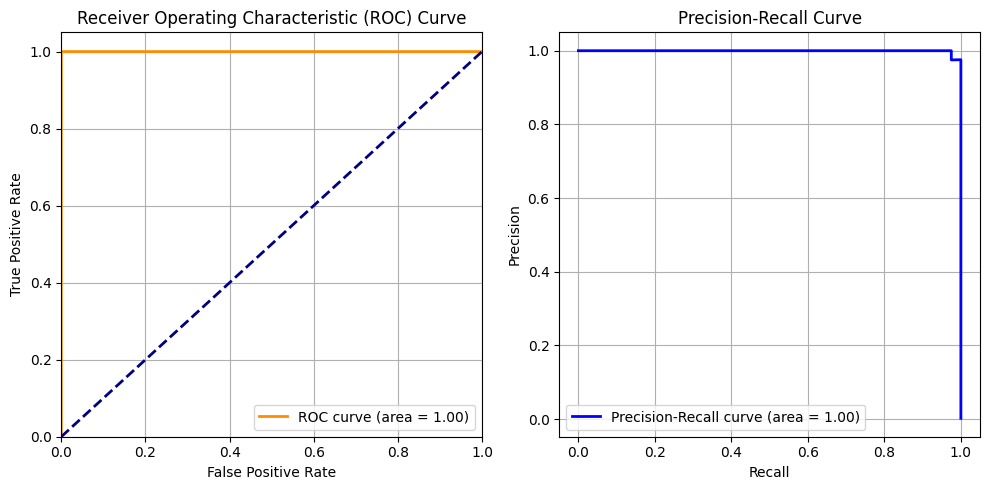

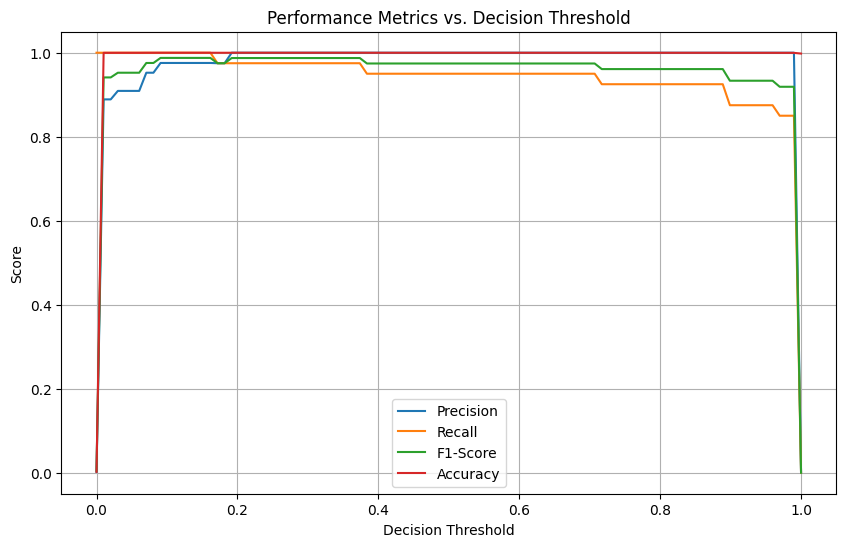

In [13]:
y_pred_proba = xgb_model.predict_proba(X_test_scaled)[:, 1]

y_pred_default = (y_pred_proba > 0.5).astype(int)
print("\n--- Evaluation with Default Threshold (0.5) ---")
print(confusion_matrix(y_test, y_pred_default))
print(classification_report(y_test, y_pred_default))

fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.grid(True)


precision, recall, thresholds_pr = precision_recall_curve(y_test, y_pred_proba)
pr_auc = average_precision_score(y_test, y_pred_proba)

plt.subplot(1, 2, 2)
plt.plot(recall, precision, color='blue', lw=2, label=f'Precision-Recall curve (area = {pr_auc:.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc="lower left")
plt.grid(True)
plt.tight_layout()
plt.show()

thresholds = np.linspace(0, 1, 100)

precision_scores = []
recall_scores = []
f1_scores = []
accuracies = []

for t in thresholds:

    y_pred_threshold = (y_pred_proba >= t).astype(int)

    precision_scores.append(precision_score(y_test, y_pred_threshold, zero_division=0))
    recall_scores.append(recall_score(y_test, y_pred_threshold, zero_division=0))
    f1_scores.append(f1_score(y_test, y_pred_threshold, zero_division=0))
    accuracies.append(accuracy_score(y_test, y_pred_threshold))

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(thresholds, precision_scores, label='Precision')
ax.plot(thresholds, recall_scores, label='Recall')
ax.plot(thresholds, f1_scores, label='F1-Score')
ax.plot(thresholds, accuracies, label='Accuracy')

ax.set_xlabel('Decision Threshold')
ax.set_ylabel('Score')
ax.set_title('Performance Metrics vs. Decision Threshold')
ax.legend()
ax.grid(True)
plt.show()

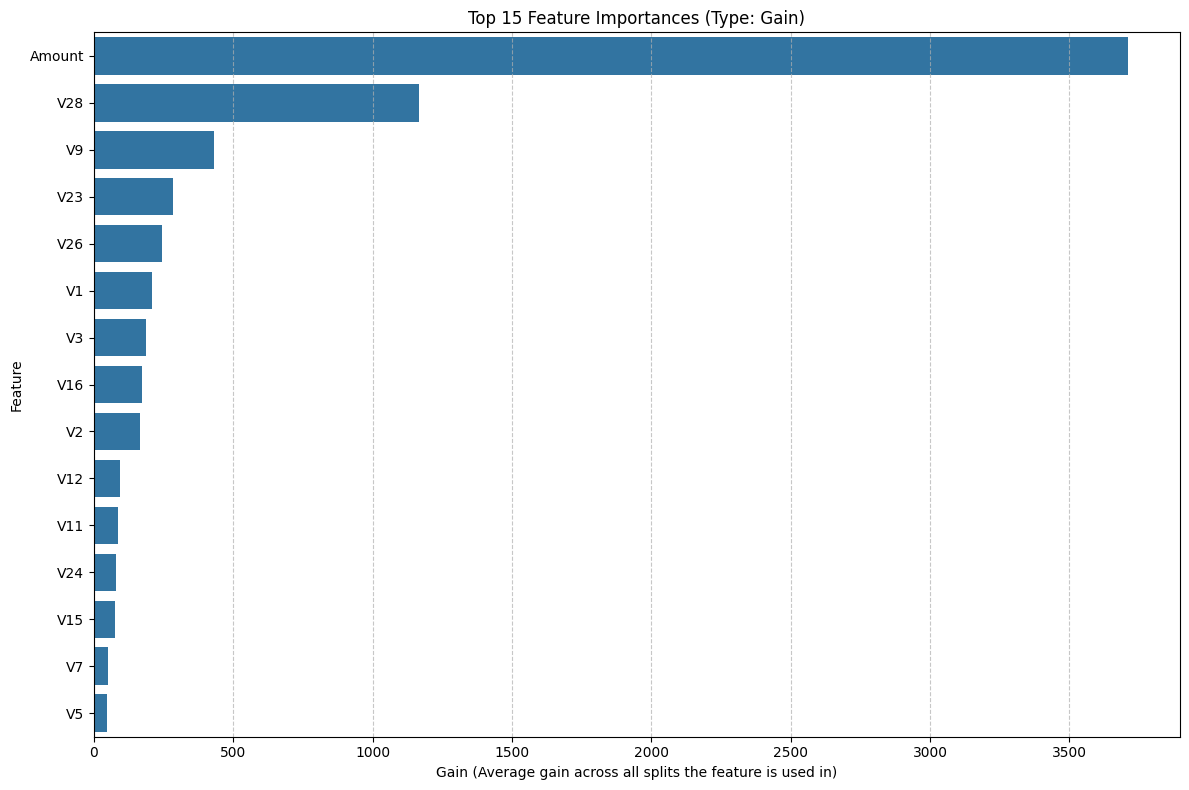

,Feature,Importance
28,Amount,3711.513428
27,V28,1165.243042
8,V9,432.949677
22,V23,283.198120
25,V26,245.667160
0,V1,208.328125
2,V3,186.060135
15,V16,173.228180
1,V2,166.047562
11,V12,94.531197


In [14]:
feature_importances = xgb_model.get_booster().get_score(importance_type='gain')

importance_df = pd.DataFrame({
    'Feature': list(feature_importances.keys()),
    'Importance': list(feature_importances.values())
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=importance_df.head(15))
plt.title('Top 15 Feature Importances (Type: Gain)')
plt.xlabel('Gain (Average gain across all splits the feature is used in)')
plt.ylabel('Feature')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

display(importance_df.head(10))